In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

import ladder
plt.close()

In [3]:
pull_predictions_from_weka("consistent_ranking")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_consistent_ranking_predictions.parquet


In [4]:
# load a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'correct_choice'] # accuracy benchmarks

COLS += ['logits_per_byte', 'logits_per_byte_corr', 'logits_per_char_corr']

df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)
print(f'Loaded {len(df):,} instance predictions')

Loaded 114,520,000 instance predictions


In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
SIZES  = df['size'].unique()
TOKEN_RATIO = df['token_ratio'].unique()

MMLU  = [t for t in TASKS if 'mmlu' in t]
TASKS = [t for t in TASKS if 'mmlu' not in t and ':para' not in t]
TASKS = sorted(TASKS)

### Running the Model Ladder

In [6]:
ladder_config_path = f'{ROOT_DIR}/olmo-repos/OLMo/scripts/scaling/cheap_decisions.json'

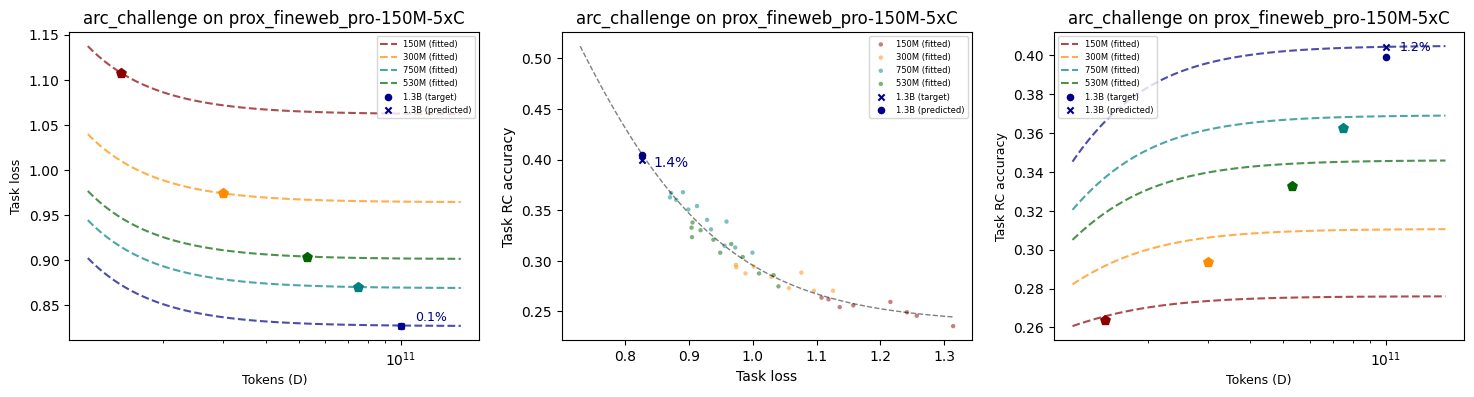

In [76]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "arc_challenge"
example_models = [m for m in MODELS if 'prox_fineweb_pro' in m]

train_models, eval_models = [m for m in example_models if '1B' not in m], [m for m in example_models if '1B' in m]
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=train_models,
    # eval_models=["peteish7", "peteish13-highlr"],
    # eval_models=["peteish7"],
    eval_models=eval_models,
    config_path=ladder_config_path,
    axes=axes[0],
)

for ax in axes[0]:
    ax.set_title(f'{task_name} on {example_models[0]}')

Fitting model ladder predictions:  44%|████▍     | 4/9 [00:07<00:09,  1.98s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling/step1.py:160: RuntimeWarning: overflow encountered in exp
  A, B = np.exp(a), np.exp(b)
/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling/predict.py:108: RuntimeWarning: overflow encountered in exp
  A, B = np.exp(a), np.exp(b)
Fitting model ladder predictions:  67%|██████▋   | 6/9 [00:13<00:07,  2.36s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling/step1.py:160: RuntimeWarning: overflow encountered in exp
  A, B = np.exp(a), np.exp(b)
/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling/predict.py:108: RuntimeWarning: overflow encountered in exp
  A, B = np.exp(a), np.exp(b)
Fitting model ladder predictions:  89%|████████▉ | 8/9 [00:17<00:02,  2.05s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling/step1.py:160: RuntimeWarning: overflow encountered in exp
  A, B = np.exp(a), np.exp(b)
/Users/dhei/ai2/new-evals/olm

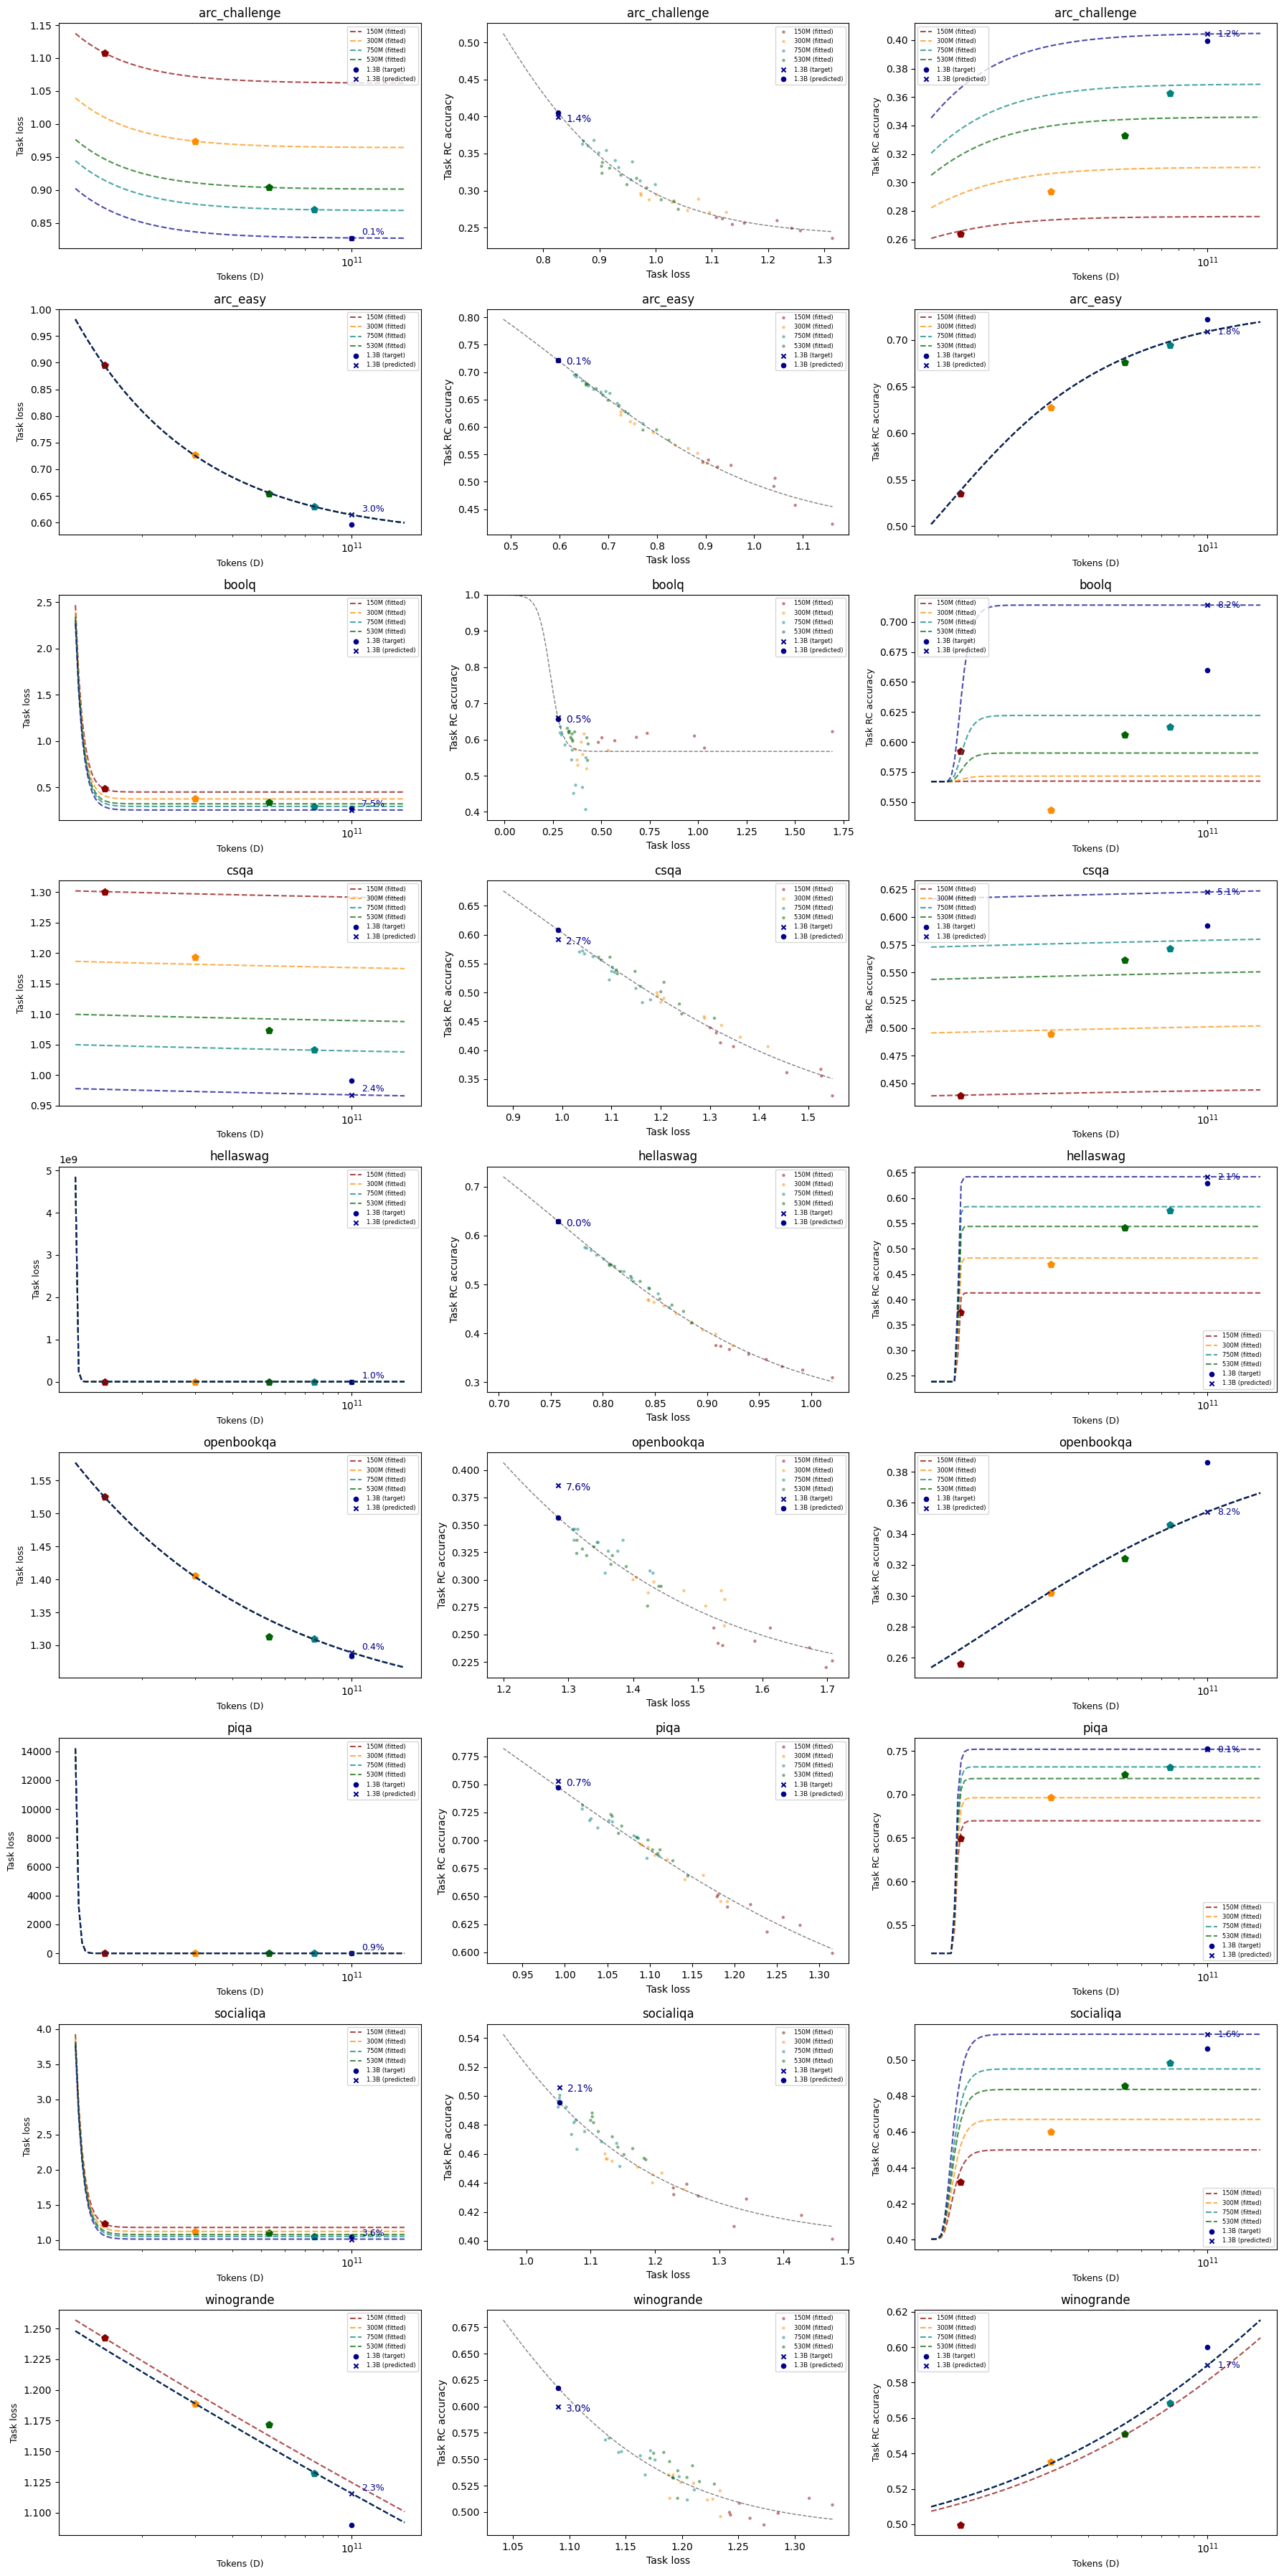

In [77]:
from tqdm import tqdm

num_rows, num_cols = len(TASKS), 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=[], columns=TASKS)

for i, task in tqdm(enumerate(TASKS), desc='Fitting model ladder predictions', total=len(TASKS)):
    try:
        train_models, eval_models = [m for m in example_models if '1B' not in m], [m for m in example_models if '1B' in m]
        _, _, _ = run_ladder(
            df,
            task_name=task,
            train_models=train_models,
            eval_models=eval_models, # ["peteish7"], # ["peteish13-highlr"],
            config_path=ladder_config_path,
            axes=axes[i],
        )
    except Exception as e:
        print(f'{task} failed: {e}')
        continue

fig.tight_layout()

### Results on All Mixes

In [112]:
from tqdm import tqdm

fitting_results_step_1 = pd.DataFrame(index=[], columns=TASKS)
fitting_results_step_2 = pd.DataFrame(index=[], columns=TASKS)
stacked_y_preds = pd.DataFrame(index=[], columns=TASKS)

for mix in tqdm(MIXES, desc='Fitting model ladder predictions', total=len(MIXES)):
    models = [model for model in MODELS if '-'.join(model.split('-')[:-2]) == mix]

    for i, task in enumerate(TASKS):
        train_models, eval_models = [m for m in models if '1B' not in m], [m for m in models if '1B' in m]
        (rel_error_step_1, rel_error_step_2, _), (step_1_y_pred, step_2_y_pred, stacked_y_pred) = run_ladder(
            df,
            task_name=task,
            train_models=train_models,
            eval_models=eval_models, # ["peteish7"], # ["peteish13-highlr"],
            config_path=ladder_config_path,
            return_preds=True
        )

        fitting_results_step_1.loc[mix, task] = rel_error_step_1
        fitting_results_step_2.loc[mix, task] = rel_error_step_2
        stacked_y_preds.loc[mix, task] = stacked_y_pred

Fitting model ladder predictions:   0%|          | 0/20 [00:00<?, ?it/s]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered in exp
  o = a / (1 + np.exp(-k * (x - x0))) + b
Fitting model ladder predictions:   5%|▌         | 1/20 [00:18<05:43, 18.06s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered in exp
  o = a / (1 + np.exp(-k * (x - x0))) + b
Fitting model ladder predictions:  90%|█████████ | 18/20 [05:26<00:35, 17.96s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:83: RuntimeWarning: overflow encountered in exp
  return np.exp(p[0] - np.log(x[0]) * p[2]) + np.exp(p[1] - np.log(x[1]) * p[3]) + p[4]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:88: RuntimeWarning: overflow encountered in exp
  grad_a = np.exp(p[0] - np.log(x[0]) * p[2])

In [118]:
print(f'Relative unsigned error for prediticting 1B-5xC (step 1):')
fitting_results_step_1['avg_error'] = fitting_results_step_1.mean(axis=1)
fitting_results_step_1 = fitting_results_step_1.abs()
fitting_results_step_1 = fitting_results_step_1.sort_values(by='avg_error', ascending=False)
fitting_results_step_1_display = fitting_results_step_1.map(lambda x: f'{round(x*100, 1)}%')
display(fitting_results_step_1_display)

print(f'Relative unsigned error for prediticting 1B-5xC (step 2):')
fitting_results_step_2['avg_error'] = fitting_results_step_2.mean(axis=1)
fitting_results_step_2 = fitting_results_step_2.abs()
fitting_results_step_2 = fitting_results_step_2.sort_values(by='avg_error', ascending=False)
fitting_results_step_2_display = fitting_results_step_2.map(lambda x: f'{round(x*100, 1)}%')
display(fitting_results_step_2_display)

Relative unsigned error for prediticting 1B-5xC (step 1):


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,avg_error
no_reddit,9.2%,15.1%,28.2%,23.4%,1.3%,8.4%,1.1%,17.6%,1.5%,11.7%
dolma-v1-6-and-sources-baseline,1.6%,14.5%,63.1%,4.5%,1.5%,0.3%,5.2%,6.1%,1.9%,11.0%
no_code,11.5%,2.2%,12.4%,2.7%,0.3%,24.5%,8.4%,23.5%,0.8%,9.6%
no_math_no_code,4.3%,0.6%,29.5%,21.8%,1.8%,6.4%,0.2%,12.9%,0.9%,8.7%
dolma17-50p-DCLM-baseline-50p,4.0%,4.3%,41.5%,16.8%,0.9%,1.9%,0.1%,0.8%,2.2%,8.1%
c4,2.4%,4.6%,41.4%,3.2%,3.9%,1.6%,2.7%,3.6%,1.9%,7.3%
dolma17-75p-DCLM-baseline-25p,3.0%,2.2%,49.9%,1.6%,1.8%,2.5%,1.7%,2.2%,0.2%,7.2%
baseline,1.9%,2.2%,24.1%,2.2%,1.9%,3.7%,0.6%,11.6%,1.2%,5.5%
falcon_and_cc_tulu_qc_top10,2.8%,0.7%,28.7%,5.7%,1.8%,1.2%,2.2%,0.6%,2.7%,5.2%
no_flan,3.9%,6.1%,22.0%,7.1%,1.3%,0.1%,2.1%,1.2%,0.0%,4.9%


Relative unsigned error for prediticting 1B-5xC (step 2):


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,avg_error
no_reddit,17.5%,17.9%,3.8%,26.0%,1.3%,17.6%,1.4%,12.9%,1.8%,11.1%
baseline,18.0%,19.2%,12.1%,13.9%,0.3%,17.6%,4.6%,8.4%,0.7%,10.5%
no_math_no_code,16.5%,13.2%,15.6%,6.2%,0.6%,20.7%,0.0%,2.0%,1.2%,8.4%
redpajama,1.6%,3.1%,2.0%,4.3%,0.3%,3.7%,0.3%,0.5%,57.7%,8.2%
no_code,14.0%,6.9%,5.5%,19.0%,0.4%,6.6%,0.3%,9.8%,4.9%,7.5%
falcon_and_cc_og_eli5_oh_top10p,0.8%,0.3%,47.0%,1.3%,1.4%,0.5%,0.3%,1.3%,8.2%,6.8%
dolma-v1-6-and-sources-baseline,3.2%,2.3%,13.9%,17.2%,0.1%,0.7%,0.9%,11.3%,5.2%,6.1%
dolma17-50p-DCLM-baseline-50p,6.5%,3.1%,10.9%,12.4%,0.8%,6.1%,0.2%,1.5%,0.3%,4.6%
dolma17-25p-DCLM-baseline-75p,4.9%,0.7%,14.5%,0.7%,0.3%,4.3%,0.7%,2.6%,11.7%,4.5%
falcon_and_cc,3.4%,0.7%,5.1%,1.4%,0.0%,5.0%,1.0%,4.2%,18.7%,4.4%


In [119]:
print('Predicted performance for 1B-5xC on all mixes:')
stacked_y_preds['macro_avg'] = stacked_y_preds.mean(axis=1)
stacked_y_preds = stacked_y_preds.sort_values(by='macro_avg', ascending=False)
stacked_y_preds_display = stacked_y_preds.map(lambda x: f'{round(x * 100, 1)}%')
stacked_y_preds_display

Predicted performance for 1B-5xC on all mixes:


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,macro_avg
prox_fineweb_pro,40.4%,70.9%,71.4%,62.3%,64.2%,35.4%,75.2%,51.4%,59.0%,58.9%
falcon_and_cc_og_eli5_oh_top10p,39.2%,73.1%,59.6%,65.2%,64.3%,38.9%,72.9%,52.1%,59.9%,58.4%
falcon_and_cc_eli5_oh_top10p,42.3%,74.0%,58.5%,61.0%,63.8%,38.7%,74.1%,50.7%,61.6%,58.3%
fineweb_edu_dedup,40.9%,76.7%,67.1%,59.0%,60.1%,35.1%,74.5%,49.5%,61.6%,58.3%
DCLM-baseline,40.6%,70.3%,62.9%,63.2%,62.7%,35.7%,73.9%,50.6%,59.7%,57.7%
dolma17-25p-DCLM-baseline-75p,38.0%,68.9%,59.8%,64.2%,61.1%,37.3%,73.3%,52.7%,63.0%,57.6%
falcon_and_cc_eli5_oh_top20p,37.2%,70.9%,62.3%,60.3%,64.4%,36.1%,74.6%,50.3%,60.6%,57.4%
falcon_and_cc_tulu_qc_top10,40.8%,72.5%,59.1%,61.4%,57.4%,39.0%,73.0%,51.5%,57.3%,56.9%
dolma17-50p-DCLM-baseline-50p,36.2%,73.4%,56.3%,62.5%,60.2%,34.9%,75.5%,51.0%,58.0%,56.4%
falcon_and_cc,32.3%,65.0%,62.6%,62.9%,61.4%,33.1%,74.2%,51.3%,56.7%,55.5%
